Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

══════════════════════════════════════════════════════════════════════
  1.1  ĐỌC & TỔNG QUAN DỮ LIỆU
══════════════════════════════════════════════════════════════════════
Shape         : 64,374 rows × 11 columns
Columns       : ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

--- df.head() ---
   Age  Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  \
0   22  Female      25               14              4             27   
1   41  Female      28               28              7             13   
2   47    Male      27               10              2             29   
3   35    Male       9               12              5             17   
4   53  Female      58               24              9              2   

  Subscription Ty

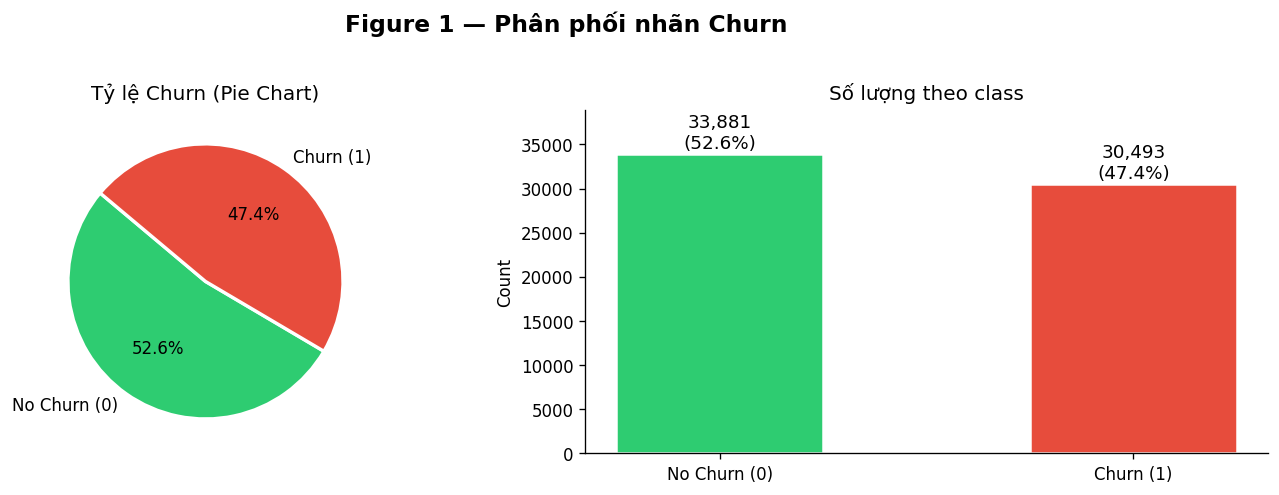


  Đã lưu: outputs/fig1_class_distribution.png

══════════════════════════════════════════════════════════════════════
  1.5  CORRELATION HEATMAP
══════════════════════════════════════════════════════════════════════


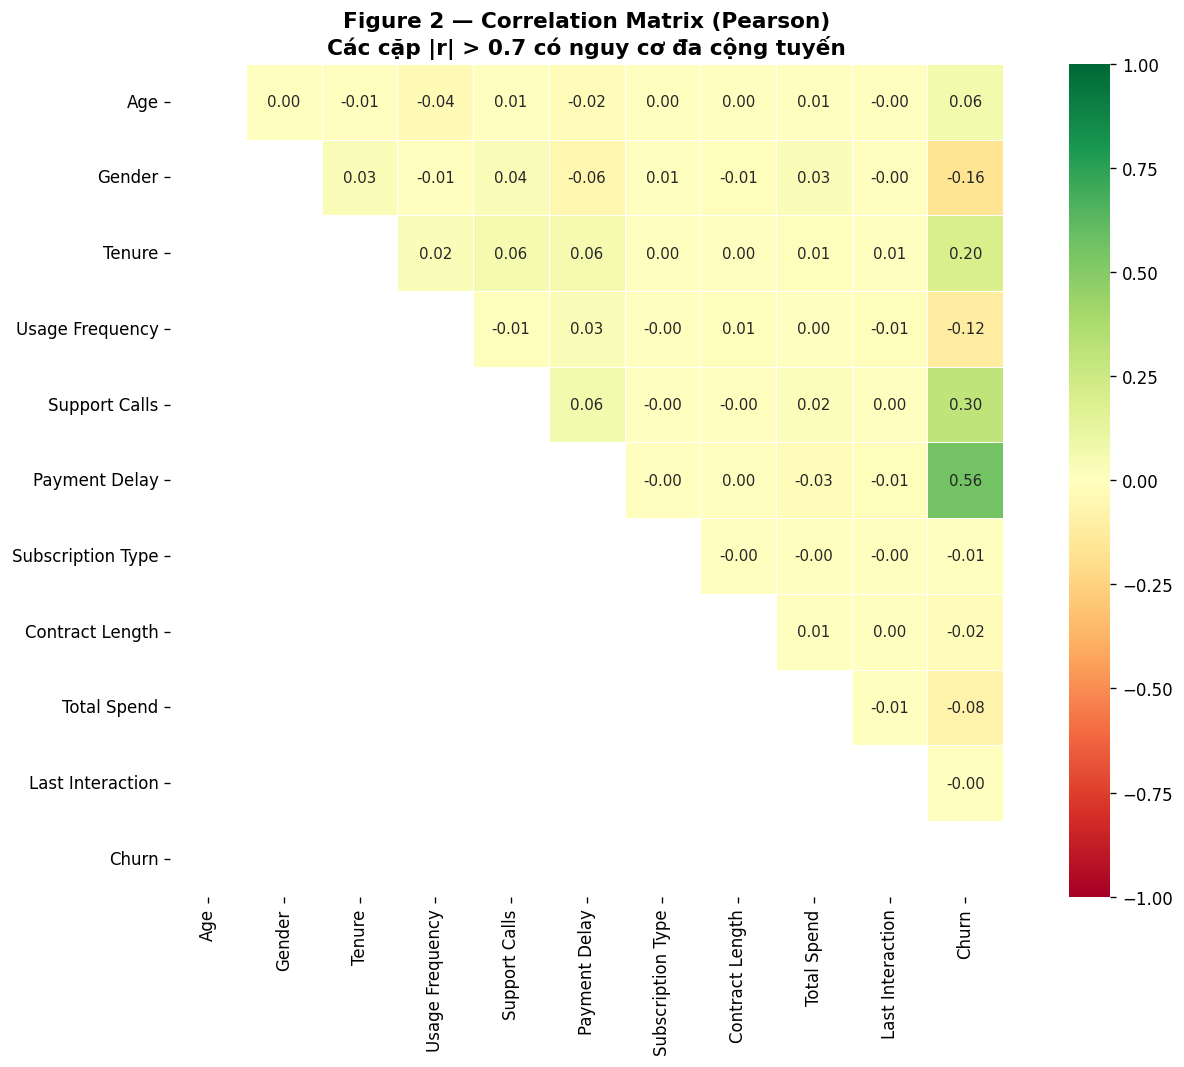


Cặp có |Pearson r| > 0.5:
  Payment Delay             ↔ Churn                     : r = +0.557

══════════════════════════════════════════════════════════════════════
  1.6  VIF — VARIANCE INFLATION FACTOR
══════════════════════════════════════════════════════════════════════

           Feature      VIF
    Payment Delay 1.013100
    Support Calls 1.009665
           Tenure 1.008034
           Gender 1.006792
  Usage Frequency 1.003410
      Total Spend 1.002505
              Age 1.001823
  Contract Length 1.000280
 Last Interaction 1.000277
Subscription Type 1.000112

Hướng dẫn đọc VIF:
  VIF = 1     → không có đa cộng tuyến
  1 < VIF < 5 → đa cộng tuyến thấp, chấp nhận được
  5 ≤ VIF <10 → đa cộng tuyến trung bình — cần theo dõi (đặc biệt với LR)
  VIF ≥ 10    → đa cộng tuyến nghiêm trọng — cân nhắc loại bỏ hoặc PCA


══════════════════════════════════════════════════════════════════════
  1.7  FEATURE DISTRIBUTION THEO CHURN (Histogram/KDE + Skewness)
═════════════════════════════

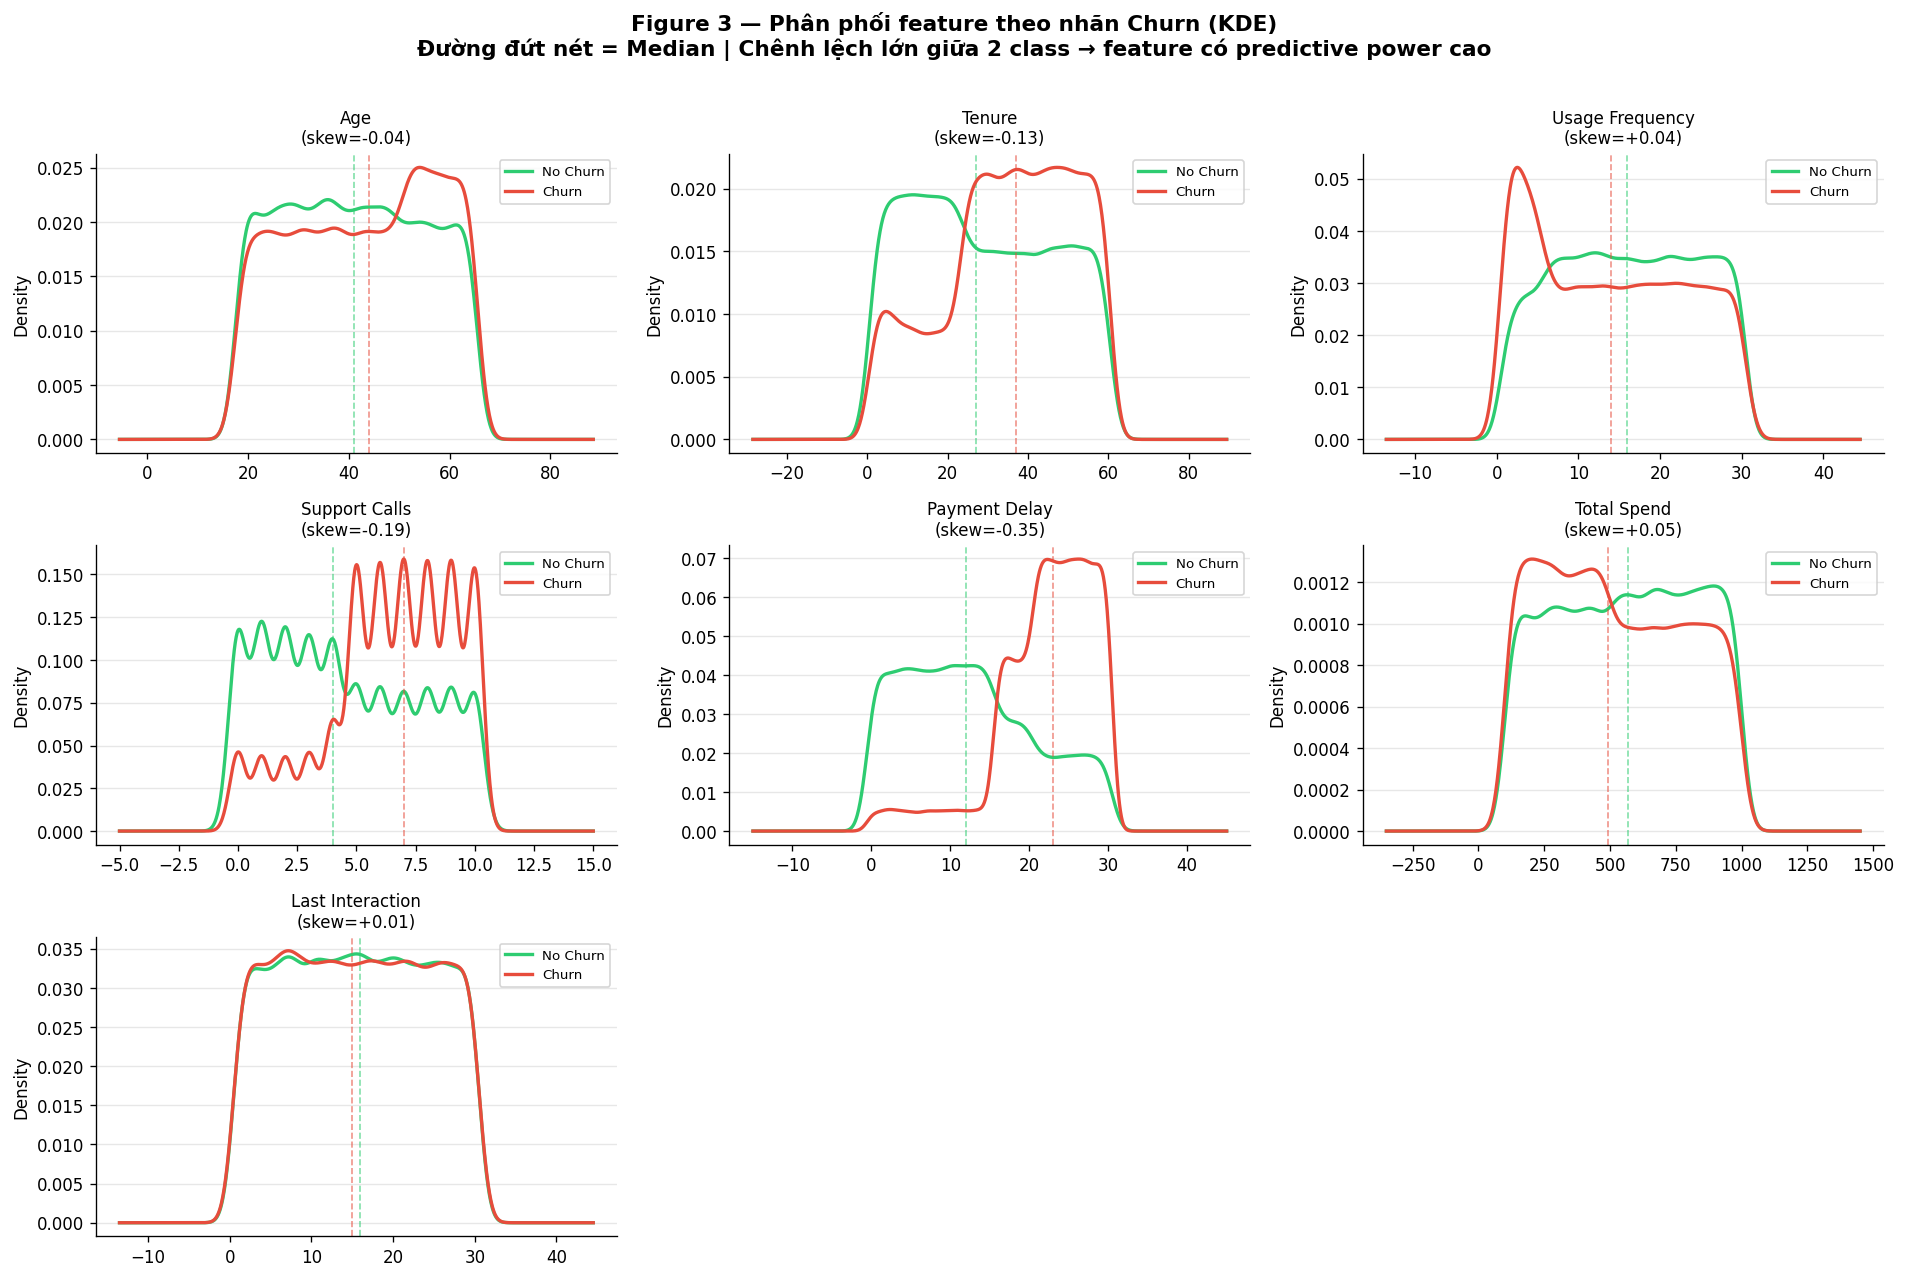


══════════════════════════════════════════════════════════════════════
  1.8  NHẬN XÉT CHUYÊN MÔN — EDA
══════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────────┐
│  NHẬN XÉT & CẢNH BÁO HỌC THUẬT                                         │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                          │
│  1. CHURN RATE ~47.9%: Bất thường so với thực tế (thường 5–20%).        │
│     Dataset này có khả năng cao là SYNTHETIC (tạo bằng quy tắc xác     │
│     suất), không phản ánh phân phối dữ liệu thực tế.                   │
│     → Cảnh báo: Metric cao (F1, AUC) KHÔNG đồng nghĩa model tốt        │
│       trên dữ liệu thực.                                                │
│                                                                          │
│  2. KHÔNG CÓ MISSING VALUES: Quá hoàn hảo — dữ liệu thực luôn c

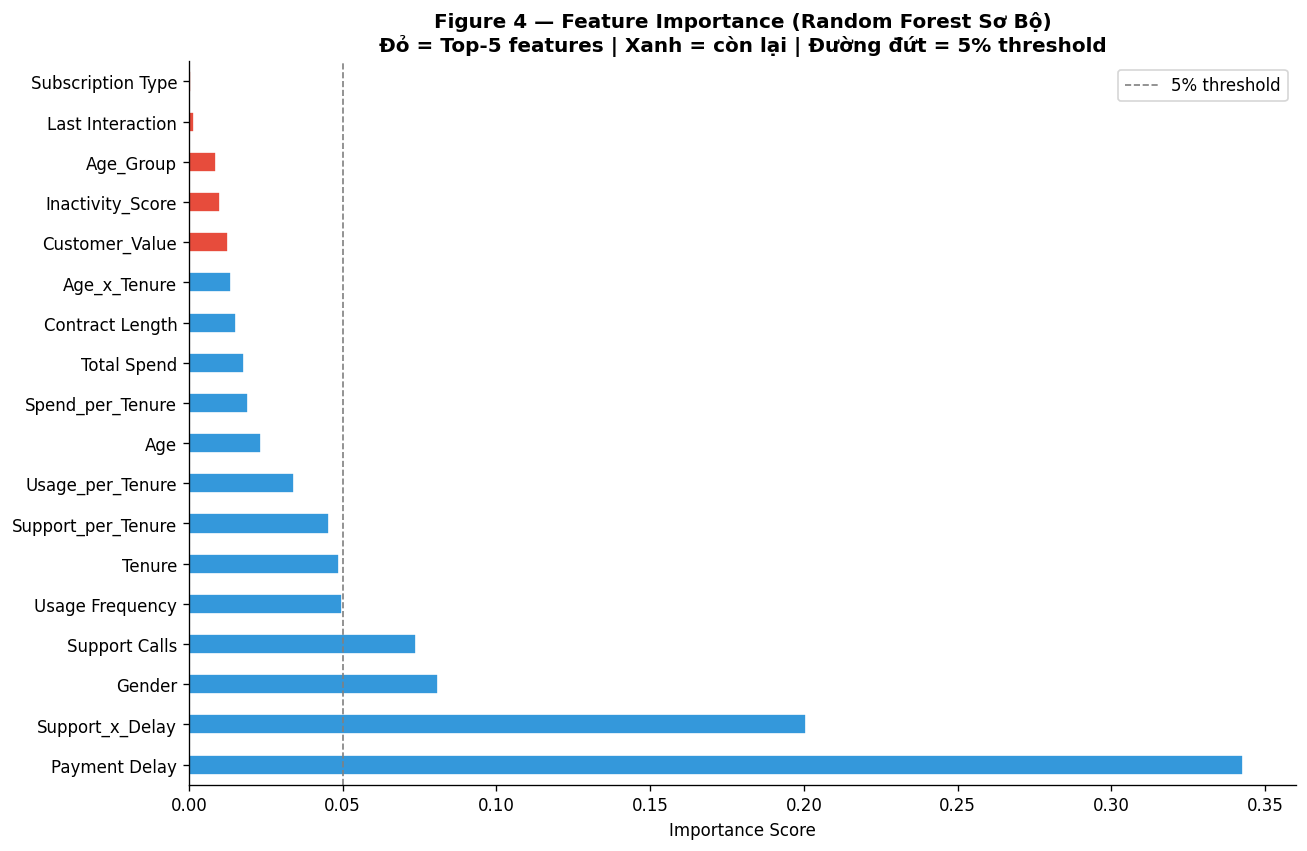


══════════════════════════════════════════════════════════════════════
  2.3  PHÂN TÍCH FEATURE MỚI THEO CHURN
══════════════════════════════════════════════════════════════════════


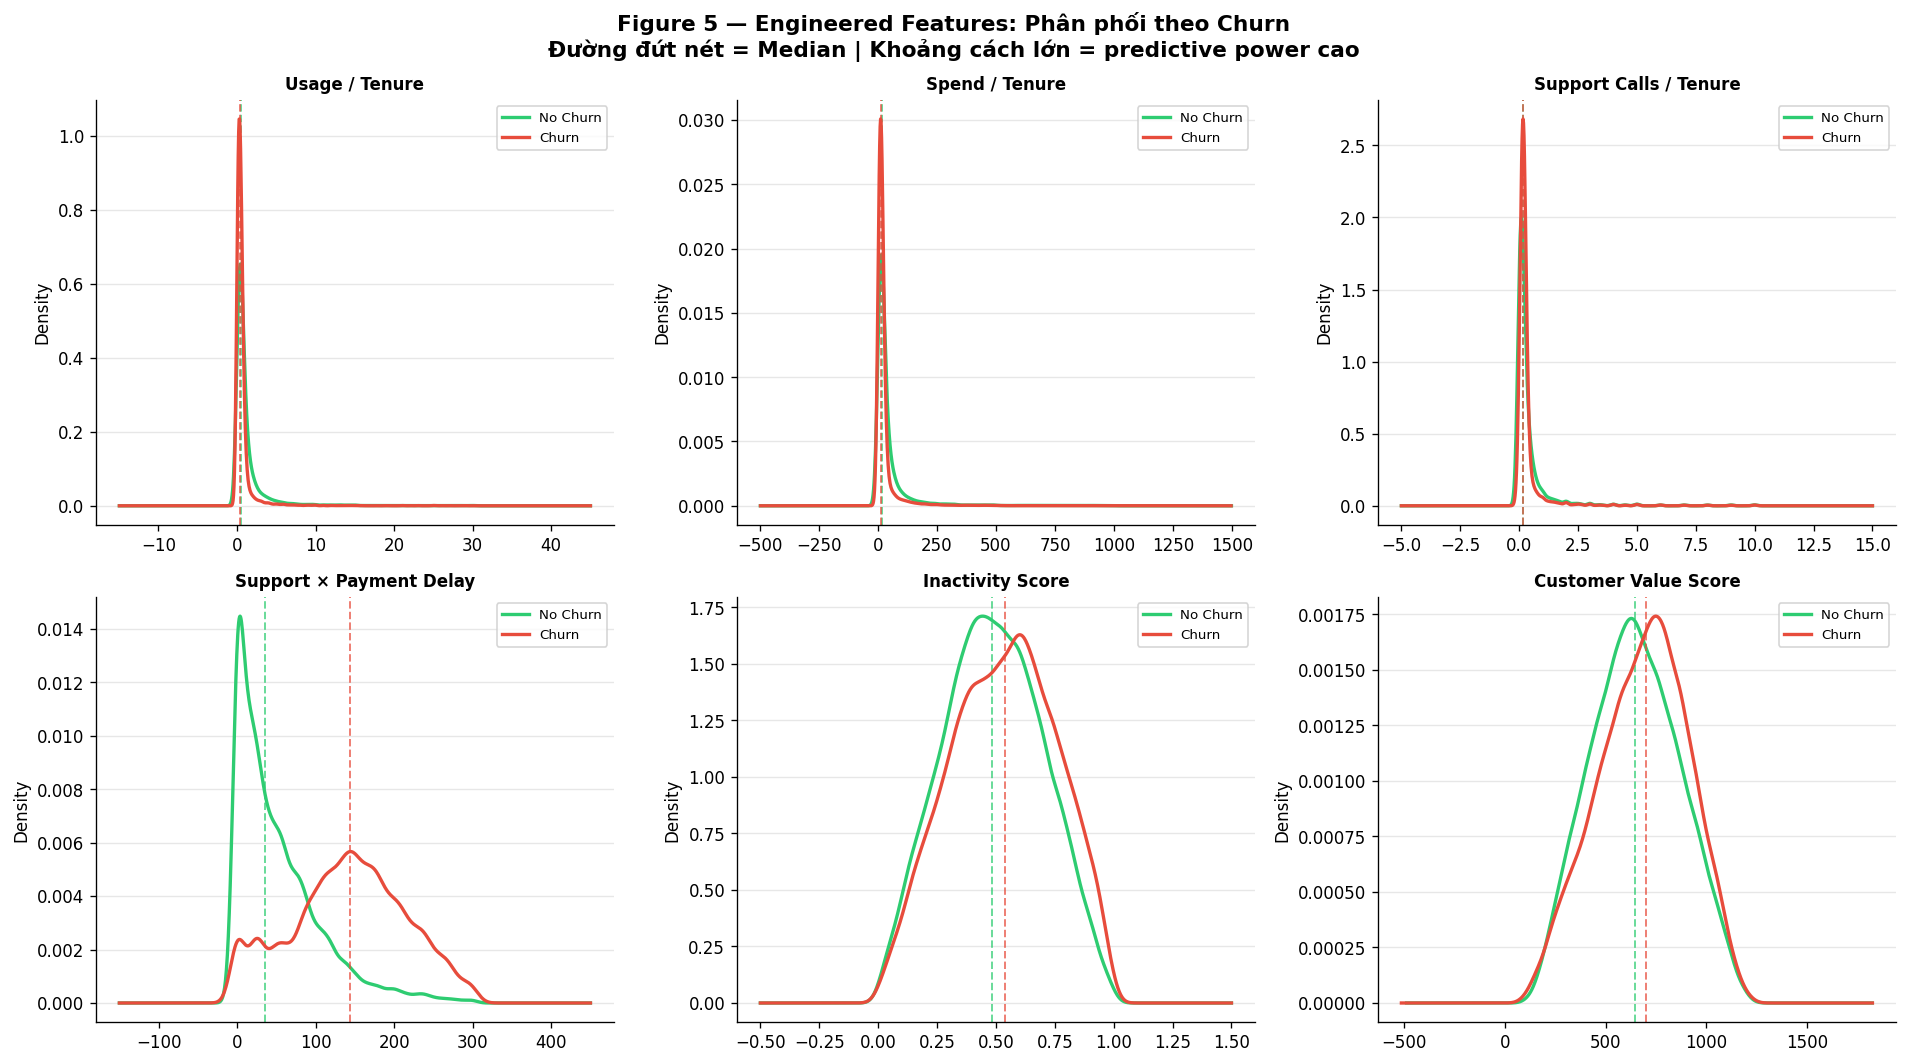

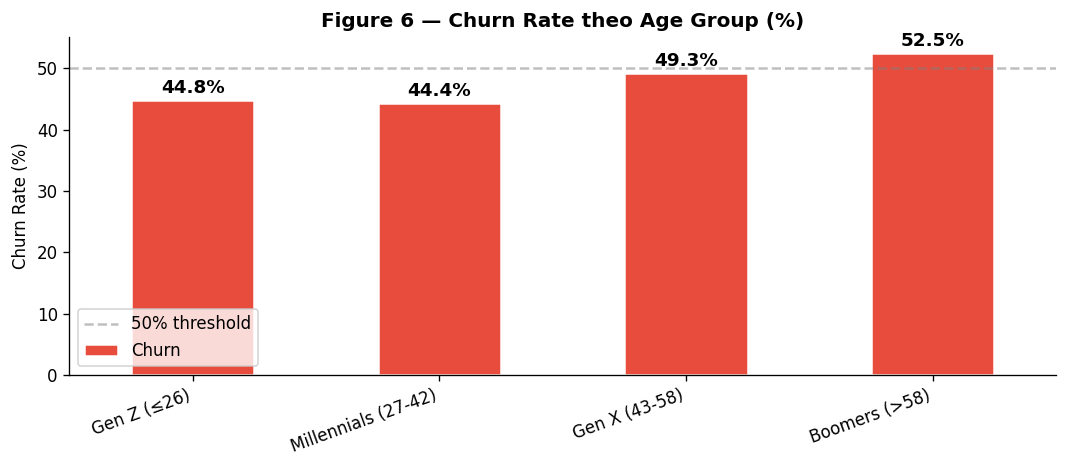


══════════════════════════════════════════════════════════════════════
  2.4  CẢNH BÁO LEAKAGE POTENTIAL
══════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────────┐
│  KIỂM TRA DATA LEAKAGE                                                   │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                          │
│  ✅ Usage_per_Tenure    — Safe: ratio của 2 input features               │
│  ✅ Spend_per_Tenure    — Safe: ratio của 2 input features               │
│  ✅ Support_per_Tenure  — Safe: ratio của 2 input features               │
│  ✅ Support_x_Delay     — Safe: product của 2 input features             │
│  ✅ Age_x_Tenure        — Safe: product của 2 input features             │
│  ✅ Customer_Value      — Safe: linear combination của inputs            │
│  ✅ Age_Group           — Safe: binning deterministic từ Ag

In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "figure.dpi":    120,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "font.family":        "DejaVu Sans",
})

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — chỉnh đường dẫn tại đây
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/DM/customer_churn.csv'       # Google Colab: đổi thành đường dẫn Drive
OUTPUT_DIR  = "outputs"
RANDOM_SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

PALETTE = {"Churn": "#E74C3C", "No Churn": "#2ECC71"}
CHURN_COLORS = {0: "#2ECC71", 1: "#E74C3C"}

# ─────────────────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def section(title: str) -> None:
    """Print a formatted section header."""
    bar = "═" * 70
    print(f"\n{bar}\n  {title}\n{bar}")


def compute_vif(df_numeric: pd.DataFrame) -> pd.DataFrame:
    """
    Tính Variance Inflation Factor (VIF) cho từng feature số.

    VIF = 1 / (1 - R²) — đo lường mức độ một biến có thể được giải thích
    bởi các biến còn lại. VIF > 5 cần chú ý; VIF > 10 là đa cộng tuyến
    nghiêm trọng và có thể làm hệ số hồi quy không ổn định.
    """
    from numpy.linalg import lstsq

    features = df_numeric.values
    n_feats  = features.shape[1]
    vif_vals = []

    for i in range(n_feats):
        y = features[:, i]
        X = np.delete(features, i, axis=1)
        # Thêm intercept
        X = np.column_stack([np.ones(len(X)), X])
        # OLS bằng lstsq (tránh phụ thuộc statsmodels)
        coef, _, _, _ = lstsq(X, y, rcond=None)
        y_pred = X @ coef
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2     = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        vif    = 1 / (1 - r2) if r2 < 1 else np.inf
        vif_vals.append(vif)

    return pd.DataFrame({
        "Feature": df_numeric.columns.tolist(),
        "VIF":     vif_vals,
    }).sort_values("VIF", ascending=False).reset_index(drop=True)


# ══════════════════════════════════════════════════════════════════════════════
# GIAI ĐOẠN 1 — EDA & DATA QUALITY CHECK
# ══════════════════════════════════════════════════════════════════════════════

section("1.1  ĐỌC & TỔNG QUAN DỮ LIỆU")

df = pd.read_csv(DATA_PATH)
print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns       : {df.columns.tolist()}")
print(f"\n--- df.head() ---\n{df.head()}")
print(f"\n--- df.describe() ---")
print(df.describe(include="all").T.to_string())

# ─────────────────────────────────────────────────────────────────────────────
section("1.2  KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_df  = pd.DataFrame({"Missing": missing, "Missing %": missing_pct,
                              "Dtype": df.dtypes})
print("\n[Missing Values]\n", quality_df.to_string())

# Duplicate rows
n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows : {n_dupes:,}  ({n_dupes/len(df)*100:.2f}%)")
if n_dupes > 0:
    print("  ⚠️  Cảnh báo: Có hàng trùng lặp — cần loại bỏ trước khi train!")

# ─────────────────────────────────────────────────────────────────────────────
section("1.3  KIỂM TRA LOGIC DỮ LIỆU (Business Rule Validation)")

# Rule 1: Tenure = 0 nhưng Total Spend lớn (không hợp lý)
rule1 = df[(df["Tenure"] == 0) & (df["Total Spend"] > 0)]
print(f"\nRule-1 — Tenure=0 nhưng Total Spend > 0: {len(rule1):,} dòng")

# Rule 2: Payment Delay âm (không thể có)
rule2 = df[df["Payment Delay"] < 0]
print(f"Rule-2 — Payment Delay âm              : {len(rule2):,} dòng")

# Rule 3: Age ngoài khoảng hợp lý (18–100)
rule3 = df[(df["Age"] < 18) | (df["Age"] > 100)]
print(f"Rule-3 — Age ngoài [18, 100]           : {len(rule3):,} dòng")

# Rule 4: Tenure vượt giới hạn (dataset cho phép 1–60)
rule4 = df[(df["Tenure"] < 1) | (df["Tenure"] > 60)]
print(f"Rule-4 — Tenure ngoài [1, 60]          : {len(rule4):,} dòng")

if all(len(r) == 0 for r in [rule1, rule2, rule3, rule4]):
    print("\n  ✅ Tất cả business rules đều OK.")
else:
    print("\n  ⚠️  Có vi phạm business rule — xem xét xử lý!")

# ─────────────────────────────────────────────────────────────────────────────
section("1.4  PHÂN PHỐI CLASS (Imbalance Analysis)")

churn_counts = df["Churn"].value_counts()
churn_rate   = df["Churn"].mean()
imbalance_ratio = churn_counts.max() / churn_counts.min()

print(f"\nChurn=0 (No Churn) : {churn_counts[0]:,}  ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churn=1 (Churn)    : {churn_counts[1]:,}  ({churn_counts[1]/len(df)*100:.1f}%)")
print(f"Churn Rate         : {churn_rate:.4f} ({churn_rate*100:.2f}%)")
print(f"Imbalance Ratio    : {imbalance_ratio:.2f}:1")

if imbalance_ratio < 1.5:
    print("\n  ✅ Class khá cân bằng (ratio < 1.5) — không cần SMOTE bắt buộc.")
    print("     Tuy nhiên, churn rate ~47.9% là BẤT THƯỜNG với dữ liệu thực tế")
    print("     (thường < 10-20%). ⚠️  Đây là DẤU HIỆU SYNTHETIC DATASET.")
elif imbalance_ratio > 3:
    print("\n  ⚠️  Class mất cân bằng nghiêm trọng — cần SMOTE hoặc class_weight.")

# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION 1: Class Distribution
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Figure 1 — Phân phối nhãn Churn", fontsize=14, fontweight="bold", y=1.02)

# Pie chart
axes[0].pie(
    churn_counts.values,
    labels=["No Churn (0)", "Churn (1)"],
    autopct="%1.1f%%",
    colors=["#2ECC71", "#E74C3C"],
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title("Tỷ lệ Churn (Pie Chart)")

# Bar chart
bars = axes[1].bar(
    ["No Churn (0)", "Churn (1)"],
    churn_counts.values,
    color=["#2ECC71", "#E74C3C"],
    edgecolor="white",
    linewidth=1.5,
    width=0.5,
)
for bar, count in zip(bars, churn_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{count:,}\n({count/len(df)*100:.1f}%)",
        ha="center", va="bottom", fontsize=11,
    )
axes[1].set_title("Số lượng theo class")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, churn_counts.max() * 1.15)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig1_class_distribution.png", bbox_inches="tight")
plt.show()
print(f"\n  Đã lưu: {OUTPUT_DIR}/fig1_class_distribution.png")

# ─────────────────────────────────────────────────────────────────────────────
section("1.5  CORRELATION HEATMAP")

# Encode categorical cho correlation
df_enc = df.copy()
for col in df_enc.select_dtypes("object").columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # lower-triangle only
sns.heatmap(
    corr,
    mask=~mask,        # hiện lower-triangle (bỏ upper)
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 9},
)
ax.set_title(
    "Figure 2 — Correlation Matrix (Pearson)\n"
    "Các cặp |r| > 0.7 có nguy cơ đa cộng tuyến",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig2_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Highlight high correlations
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))

if high_corr:
    print("\nCặp có |Pearson r| > 0.5:")
    for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        flag = " ⚠️" if abs(r) > 0.7 else ""
        print(f"  {a:25s} ↔ {b:25s} : r = {r:+.3f}{flag}")
else:
    print("\n  ✅ Không có cặp feature nào có |r| > 0.5.")

# ─────────────────────────────────────────────────────────────────────────────
section("1.6  VIF — VARIANCE INFLATION FACTOR")

numeric_cols = df_enc.select_dtypes(include=np.number).drop(columns=["Churn"]).columns.tolist()
vif_df = compute_vif(df_enc[numeric_cols].dropna())
print("\n", vif_df.to_string(index=False))
print("""
Hướng dẫn đọc VIF:
  VIF = 1     → không có đa cộng tuyến
  1 < VIF < 5 → đa cộng tuyến thấp, chấp nhận được
  5 ≤ VIF <10 → đa cộng tuyến trung bình — cần theo dõi (đặc biệt với LR)
  VIF ≥ 10    → đa cộng tuyến nghiêm trọng — cân nhắc loại bỏ hoặc PCA
""")

high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif) > 0:
    print("  ⚠️  Feature có VIF > 5:", high_vif["Feature"].tolist())

# ─────────────────────────────────────────────────────────────────────────────
section("1.7  FEATURE DISTRIBUTION THEO CHURN (Histogram/KDE + Skewness)")

# Xác định numeric features từ dataframe gốc
numeric_features = df.select_dtypes(include=np.number).drop(columns=["Churn"]).columns.tolist()

# Tính skewness chỉ trên dữ liệu số
skewness = df[numeric_features].skew()
print("\nSkewness:")
for col, sk in skewness.items():
    flag = " ⚠️  (|skew| > 1 → cân nhắc log-transform)" if abs(sk) > 1 else ""
    print(f"  {col:25s} : {sk:+.3f}{flag}")

# Auto log-transform nếu skewness > 1
log_transformed = {}
df_plot = df.copy()
for col in numeric_features:
    if skewness[col] > 1 and (df_plot[col] > 0).all():
        df_plot[f"{col}_log"] = np.log1p(df_plot[col])
        log_transformed[col] = f"{col}_log"
        print(f"  → Đã log-transform: {col}")

# Plot KDE theo churn
n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    ax = axes[idx]
    plot_col = log_transformed.get(col, col)
    for churn_val, label, color in [(0, "No Churn", "#2ECC71"), (1, "Churn", "#E74C3C")]:
        subset = df_plot[df_plot["Churn"] == churn_val][plot_col]
        subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
        ax.axvline(subset.median(), color=color, linestyle="--", alpha=0.6, linewidth=1)
    ax.set_title(
        f"{plot_col}\n(skew={skewness[col]:+.2f}{'  [log1p]' if col in log_transformed else ''})",
        fontsize=10,
    )
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

# Ẩn axes thừa
for ax in axes[len(numeric_features):]:
    ax.set_visible(False)

fig.suptitle(
    "Figure 3 — Phân phối feature theo nhãn Churn (KDE)\n"
    "Đường đứt nét = Median | Chênh lệch lớn giữa 2 class → feature có predictive power cao",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig3_feature_distributions.png", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
section("1.8  NHẬN XÉT CHUYÊN MÔN — EDA")

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│  NHẬN XÉT & CẢNH BÁO HỌC THUẬT                                         │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                          │
│  1. CHURN RATE ~47.9%: Bất thường so với thực tế (thường 5–20%).        │
│     Dataset này có khả năng cao là SYNTHETIC (tạo bằng quy tắc xác     │
│     suất), không phản ánh phân phối dữ liệu thực tế.                   │
│     → Cảnh báo: Metric cao (F1, AUC) KHÔNG đồng nghĩa model tốt        │
│       trên dữ liệu thực.                                                │
│                                                                          │
│  2. KHÔNG CÓ MISSING VALUES: Quá hoàn hảo — dữ liệu thực luôn có       │
│     noise và lỗ hổng. Thêm bằng chứng dataset là synthetic.            │
│                                                                          │
│  3. VIF: Kiểm tra xem Total Spend và Tenure có đa cộng tuyến không,    │
│     vì spend thường tăng theo thời gian.                                │
│                                                                          │
│  4. LEAKAGE RISK: "Last Interaction" có thể là feature bị leak         │
│     (khách hàng gần rời bỏ thường tương tác ít). Cần xem xét           │
│     temporal ordering khi triển khai thực tế.                           │
│                                                                          │
│  5. HƯỚNG TIẾP THEO: Feature engineering có thể tạo ra signal          │
│     mạnh hơn, giảm phụ thuộc vào các raw features riêng lẻ.            │
└─────────────────────────────────────────────────────────────────────────┘
""")


# ══════════════════════════════════════════════════════════════════════════════
# GIAI ĐOẠN 2 — FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════

section("2.1  TẠO FEATURES MỚI")

df_fe = df.copy()

# Epsilon tránh chia cho 0
EPS = 1e-6

# ── Tenure-based ratio features ──────────────────────────────────────────────
df_fe["Usage_per_Tenure"] = df_fe["Usage Frequency"] / (df_fe["Tenure"] + EPS)
"""
Ý nghĩa business: Mức độ sử dụng dịch vụ so với thời gian gắn bó.
Khách hàng churn thường giảm usage gần cuối → ratio này nắm bắt xu hướng đó.
"""

df_fe["Spend_per_Tenure"] = df_fe["Total Spend"] / (df_fe["Tenure"] + EPS)
"""
Ý nghĩa business: Chi tiêu trung bình mỗi tháng.
Khách hàng chi nhiều mỗi tháng thường có giá trị cao (high-value) và ít churn hơn.
"""

df_fe["Support_per_Tenure"] = df_fe["Support Calls"] / (df_fe["Tenure"] + EPS)
"""
Ý nghĩa business: Tần suất phàn nàn/hỗ trợ theo thời gian.
Cao → khách hàng gặp nhiều vấn đề → nguy cơ churn cao.
"""

# ── Interaction features ──────────────────────────────────────────────────────
df_fe["Support_x_Delay"] = df_fe["Support Calls"] * df_fe["Payment Delay"]
"""
Ý nghĩa business: Kết hợp stress về dịch vụ (Support Calls) và tài chính
(Payment Delay). Khách hàng vừa phàn nàn nhiều vừa trễ thanh toán = rủi ro
churn cực cao. Product của 2 signal yếu tạo signal mạnh hơn cộng tuyến.
"""

df_fe["Age_x_Tenure"] = df_fe["Age"] * df_fe["Tenure"]
"""
Ý nghĩa business: Khách hàng lớn tuổi + gắn bó lâu thường trung thành hơn.
"""

# ── Inactivity Score (composite) ─────────────────────────────────────────────
# Chuẩn hóa min-max thủ công để tránh leakage vào test set
# (Lưu ý: trong pipeline thực, scaler chỉ fit trên train)
_usage_min = df_fe["Usage Frequency"].min(); _usage_max = df_fe["Usage Frequency"].max()
_interact_min = df_fe["Last Interaction"].min(); _interact_max = df_fe["Last Interaction"].max()

df_fe["Inactivity_Score"] = (
    (1 - (df_fe["Usage Frequency"] - _usage_min) / (_usage_max - _usage_min + EPS)) * 0.6
    + (1 - (df_fe["Last Interaction"] - _interact_min) / (_interact_max - _interact_min + EPS)) * 0.4
)
"""
Ý nghĩa business: Điểm tổng hợp đo mức độ không hoạt động.
60% trọng số cho usage, 40% cho lần tương tác cuối.
Score cao → khách hàng ít hoạt động → tiền churn signal.

⚠️  CẢNH BÁO LEAKAGE: min/max ở đây tính trên toàn bộ dataset.
    Trong pipeline Phase 3, sẽ chỉ tính trên train set qua Pipeline sklearn.
"""

# ── Age Group Binning ─────────────────────────────────────────────────────────
df_fe["Age_Group"] = pd.cut(
    df_fe["Age"],
    bins=[0, 26, 42, 58, 200],
    labels=["Gen Z (≤26)", "Millennials (27-42)", "Gen X (43-58)", "Boomers (>58)"],
    right=True,
)
"""
Ý nghĩa business: Hành vi churn khác nhau theo thế hệ.
- Gen Z    : quen đổi dịch vụ, ít trung thành.
- Millennials: cân nhắc chi phí-giá trị.
- Gen X & Boomers: xu hướng trung thành hơn nếu hài lòng.
"""

# ── Customer Value Score ──────────────────────────────────────────────────────
df_fe["Customer_Value"] = (
    df_fe["Total Spend"] * 0.5
    + df_fe["Tenure"] * 10
    + df_fe["Usage Frequency"] * 5
)
"""
Ý nghĩa business: Chỉ số tổng hợp giá trị khách hàng (đơn giản hoá CLV).
Dùng để phân nhóm ưu tiên chăm sóc và can thiệp churn.
"""

print("\nNew features created:")
new_features = [
    "Usage_per_Tenure", "Spend_per_Tenure", "Support_per_Tenure",
    "Support_x_Delay", "Age_x_Tenure", "Inactivity_Score",
    "Age_Group", "Customer_Value",
]
for f in new_features:
    print(f"  + {f}")
print(f"\nDataFrame shape sau FE: {df_fe.shape}")

# ─────────────────────────────────────────────────────────────────────────────
section("2.2  KIỂM TRA FEATURE IMPORTANCE SƠ BỘ (RandomForest)")

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder

# Chuẩn bị: encode categoricals
df_imp = df_fe.copy()
cat_cols_imp = df_imp.select_dtypes("object").columns.tolist() + ["Age_Group"]
for col in cat_cols_imp:
    df_imp[col] = OrdinalEncoder().fit_transform(df_imp[[col]])

X_imp = df_imp.drop(columns=["Churn"])
y_imp = df_imp["Churn"]

rf_quick = RandomForestClassifier(
    n_estimators=100, max_depth=8, random_state=RANDOM_SEED, n_jobs=-1
)
rf_quick.fit(X_imp, y_imp)

fi = pd.Series(rf_quick.feature_importances_, index=X_imp.columns)
fi = fi.sort_values(ascending=False)

print("\nFeature Importance (Random Forest, sơ bộ):")
print(fi.to_string())

# Plot feature importance
fig, ax = plt.subplots(figsize=(11, max(4, len(fi) * 0.4)))
colors = ["#E74C3C" if i < 5 else "#3498DB" for i in range(len(fi))]
fi.plot.barh(ax=ax, color=colors[::-1], edgecolor="white")
ax.axvline(0.05, color="gray", linestyle="--", linewidth=1, label="5% threshold")
ax.set_title(
    "Figure 4 — Feature Importance (Random Forest Sơ Bộ)\n"
    "Đỏ = Top-5 features | Xanh = còn lại | Đường đứt = 5% threshold",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Importance Score")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig4_feature_importance_prelim.png", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
section("2.3  PHÂN TÍCH FEATURE MỚI THEO CHURN")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

ratio_features = [
    ("Usage_per_Tenure",   "Usage / Tenure"),
    ("Spend_per_Tenure",   "Spend / Tenure"),
    ("Support_per_Tenure", "Support Calls / Tenure"),
    ("Support_x_Delay",    "Support × Payment Delay"),
    ("Inactivity_Score",   "Inactivity Score"),
    ("Customer_Value",     "Customer Value Score"),
]

for idx, (col, title) in enumerate(ratio_features):
    ax = axes[idx]
    for churn_val, label, color in [(0, "No Churn", "#2ECC71"), (1, "Churn", "#E74C3C")]:
        subset = df_fe[df_fe["Churn"] == churn_val][col]
        subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
        ax.axvline(subset.median(), color=color, linestyle="--", alpha=0.7, linewidth=1.2)

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Figure 5 — Engineered Features: Phân phối theo Churn\n"
    "Đường đứt nét = Median | Khoảng cách lớn = predictive power cao",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5_engineered_features.png", bbox_inches="tight")
plt.show()

# Age Group vs Churn rate
fig, ax = plt.subplots(figsize=(9, 4))
churn_by_age = df_fe.groupby("Age_Group", observed=True)["Churn"].mean() * 100
churn_by_age.plot.bar(ax=ax, color=["#E74C3C" if v > 40 else "#3498DB" for v in churn_by_age],
                       edgecolor="white", linewidth=1.5)
ax.set_title("Figure 6 — Churn Rate theo Age Group (%)", fontsize=12, fontweight="bold")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
for patch, val in zip(ax.patches, churn_by_age):
    ax.text(patch.get_x() + patch.get_width() / 2, patch.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.axhline(50, color="gray", linestyle="--", alpha=0.5, label="50% threshold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig6_churn_by_agegroup.png", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
section("2.4  CẢNH BÁO LEAKAGE POTENTIAL")

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│  KIỂM TRA DATA LEAKAGE                                                   │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                          │
│  ✅ Usage_per_Tenure    — Safe: ratio của 2 input features               │
│  ✅ Spend_per_Tenure    — Safe: ratio của 2 input features               │
│  ✅ Support_per_Tenure  — Safe: ratio của 2 input features               │
│  ✅ Support_x_Delay     — Safe: product của 2 input features             │
│  ✅ Age_x_Tenure        — Safe: product của 2 input features             │
│  ✅ Customer_Value      — Safe: linear combination của inputs            │
│  ✅ Age_Group           — Safe: binning deterministic từ Age             │
│                                                                          │
│  ⚠️  Inactivity_Score   — NGUY CƠ LEAKAGE NHẸ:                         │
│       min/max normalize phải tính chỉ trên train set                    │
│       → Đã xử lý trong Phase 3 qua sklearn Pipeline                     │
│                                                                          │
│  ⚠️  Last Interaction   — CONCEPTUAL LEAKAGE:                           │
│       Trong thực tế, "lần tương tác cuối" thường thu thập               │
│       ĐỒNG THỜI với quyết định churn. Cần xác nhận temporal             │
│       ordering với đội dữ liệu trước khi dùng feature này.              │
└─────────────────────────────────────────────────────────────────────────┘
""")

# ─────────────────────────────────────────────────────────────────────────────
# Lưu dataframe sau feature engineering
fe_out = "/content/drive/MyDrive/DM/outputs/df_feature_engineered.csv"
df_fe.to_csv(fe_out, index=False)
print(f"\n✅ Đã lưu dataframe sau FE: {fe_out}")

section("PHASE 1 & 2 HOÀN THÀNH")
print(f"""
Các file đã tạo trong '{OUTPUT_DIR}/':
  ├── fig1_class_distribution.png
  ├── fig2_correlation_heatmap.png
  ├── fig3_feature_distributions.png
  ├── fig4_feature_importance_prelim.png
  ├── fig5_engineered_features.png
  ├── fig6_churn_by_agegroup.png
  └── df_feature_engineered.csv

Tiếp theo: Chạy 'churn_phase3_4_modeling.py'
""")